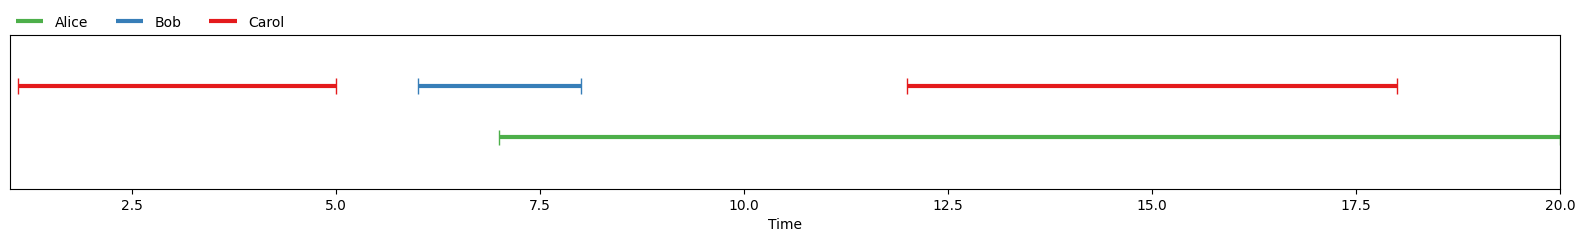

In [3]:
from pyannote.core import Annotation, Segment

annotation = Annotation()
annotation[Segment(1.1, 5)] = 'Carol'
annotation[Segment(6, 8)] = 'Bob'
annotation[Segment(12, 18)] = 'Carol'
annotation[Segment(7, 20)] = 'Alice'
annotation

In [8]:
annotation_str = str(annotation)

In [1]:
from transformers import AutoTokenizer, T5EncoderModel

name = "google/byt5-small"
text_tokenizer = AutoTokenizer.from_pretrained(name)
text_encoder = T5EncoderModel.from_pretrained(name).eval()

tokenized = text_tokenizer.batch_encode_plus(
    [annotation_str],
    return_tensors="pt",
    padding="longest",
)

/home/harry/diarisation/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'annotation_str' is not defined

In [19]:
import torch
decoded_texts = [text_tokenizer.decode(tokens, skip_special_tokens=True) for tokens in tokenized.input_ids]

In [2]:
text_tokenizer.vocab_size

256